# Event Output Visualization

This notebook loads the processed AAPL H=5 event-window datasets and generates the event table and positioning plot used in the README.

Inputs:
- `data/aapl_h5_selected_events.json`
- `data/aapl_h5_earnings_events.json`

Outputs:
- `figures/aapl_event_table.png`
- `figures/aapl_event_positioning.png`

In [1]:
from dataclasses import dataclass
import pandas as pd
from typing import Optional

@dataclass
class TrajectoryWindow:
    start_idx: int
    end_idx: int
    start_date: pd.Timestamp
    end_date: pd.Timestamp
    horizon: int
    start_price: float
    end_price: float
    simple_return: float
    abs_return: float
    llm_true_agreement: Optional[float] = None
    llm_category: Optional[str] = None
    llm_category_agreement: Optional[float] = None
    llm_note: Optional[str] = None


In [2]:
import json

from pathlib import Path

pathllm = Path("data/aapl_h5_selected_events.json")
pathearning = Path("data/aapl_h5_earnings_events.json")
def load_windows(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    llmselected = []

    for d in data:
        w = TrajectoryWindow(
            start_idx=d["start_idx"],
            end_idx=d["end_idx"],
            start_date=pd.Timestamp(d["start_date"]),
            end_date=pd.Timestamp(d["end_date"]),
            horizon=d["horizon"],
            start_price=d["start_price"],
            end_price=d["end_price"],
            simple_return=d["simple_return"],
            abs_return=d["abs_return"],
        )

        # restore optional fields
        w.llm_true_agreement = d.get("llm_true_agreement")
        w.llm_category = d.get("llm_category")
        w.llm_category_agreement = d.get("llm_category_agreement")
        w.llm_note = d.get("llm_note")

        llmselected.append(w)

    return llmselected
llmselected=load_windows(pathllm)
earn_windows=load_windows(pathearning)

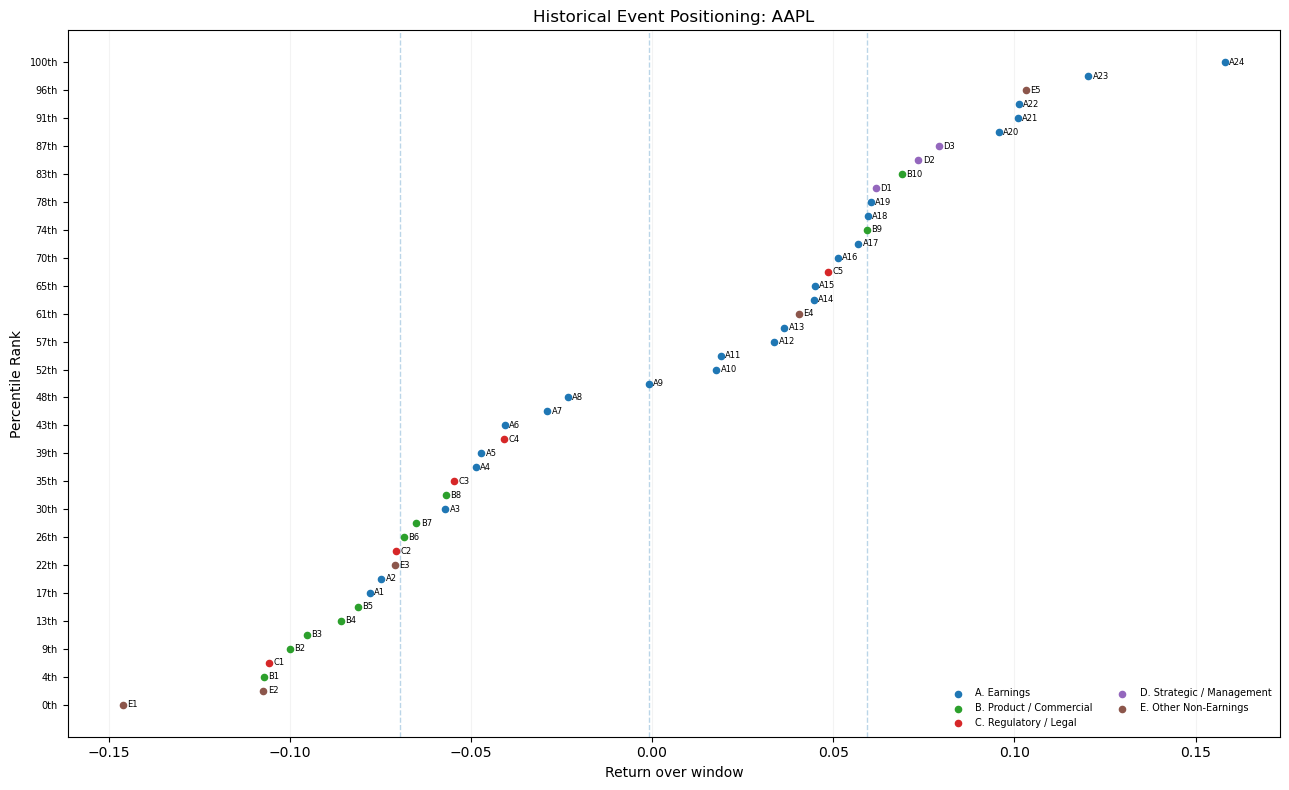

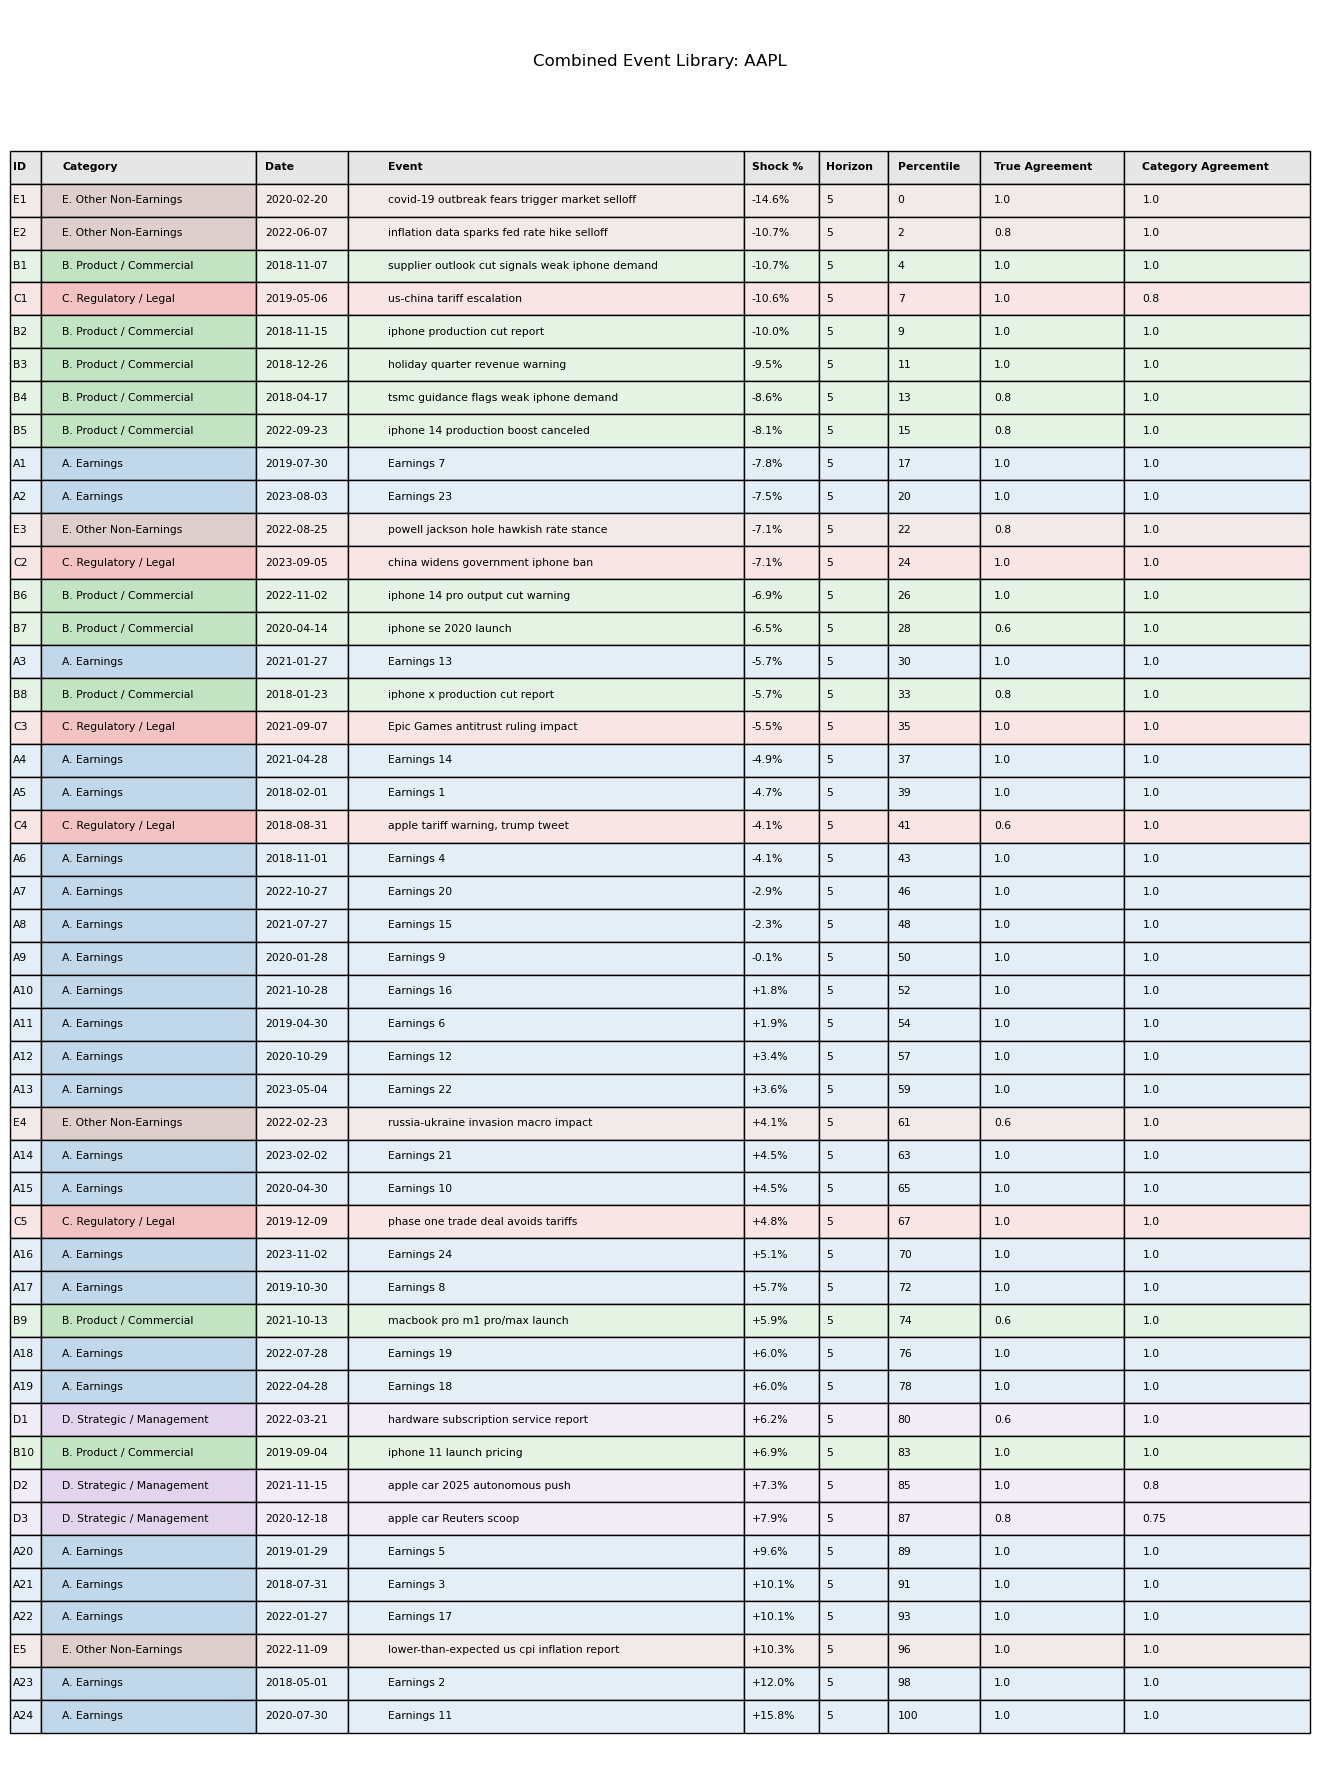

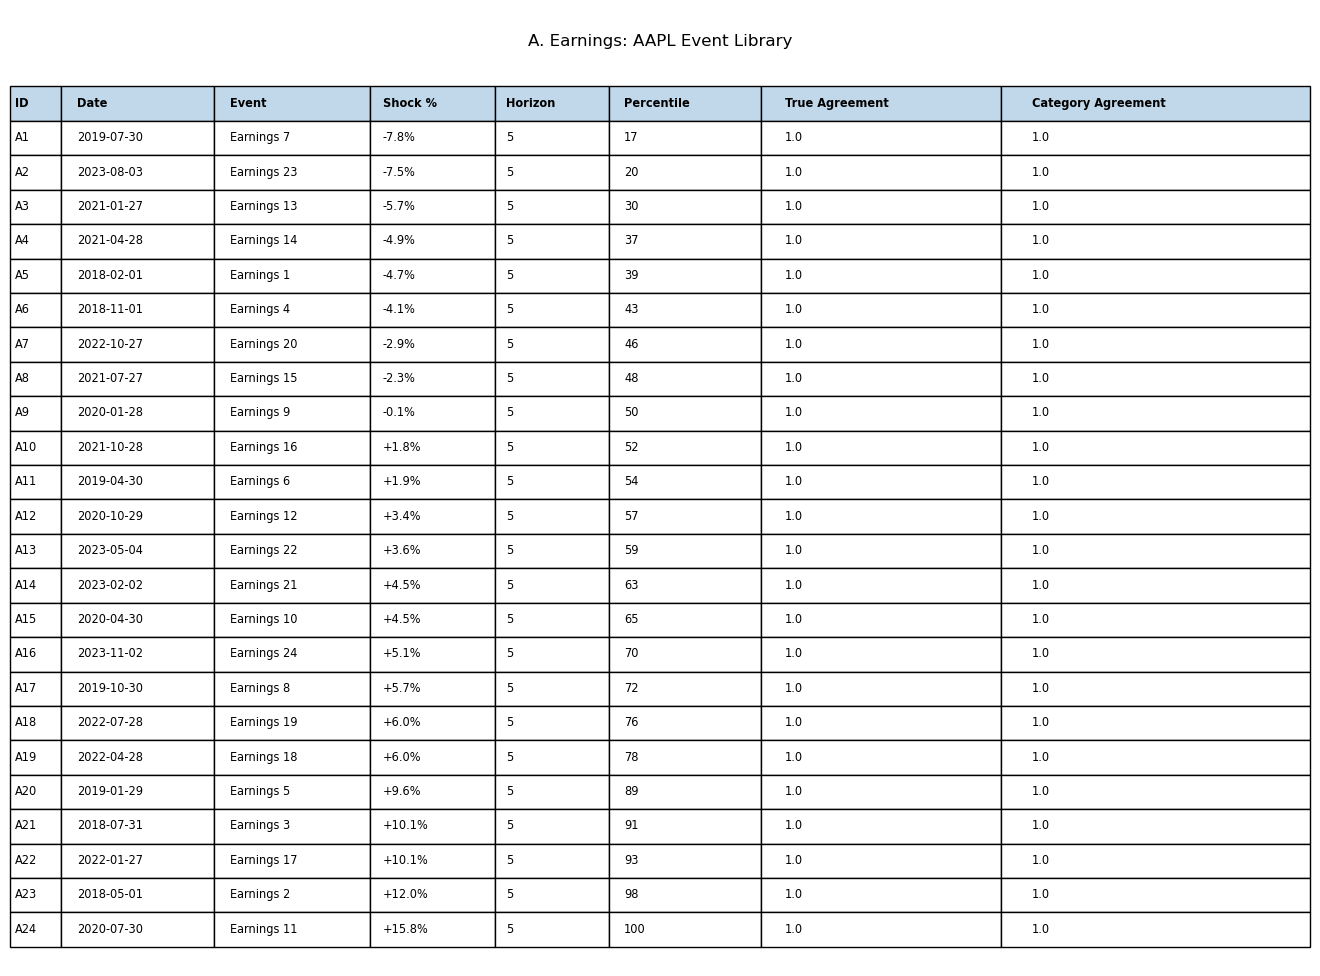

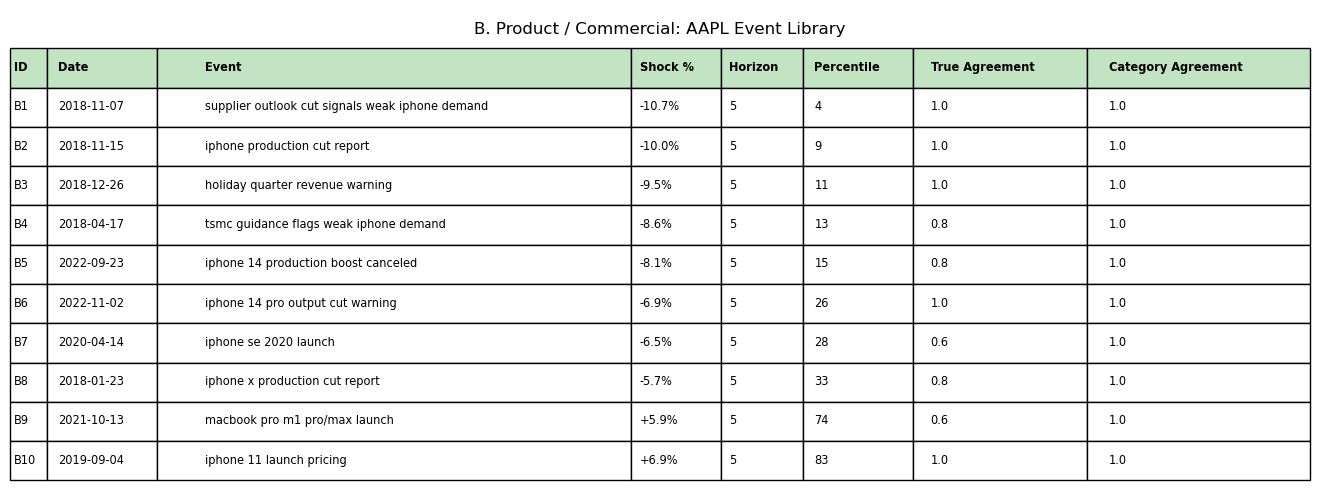

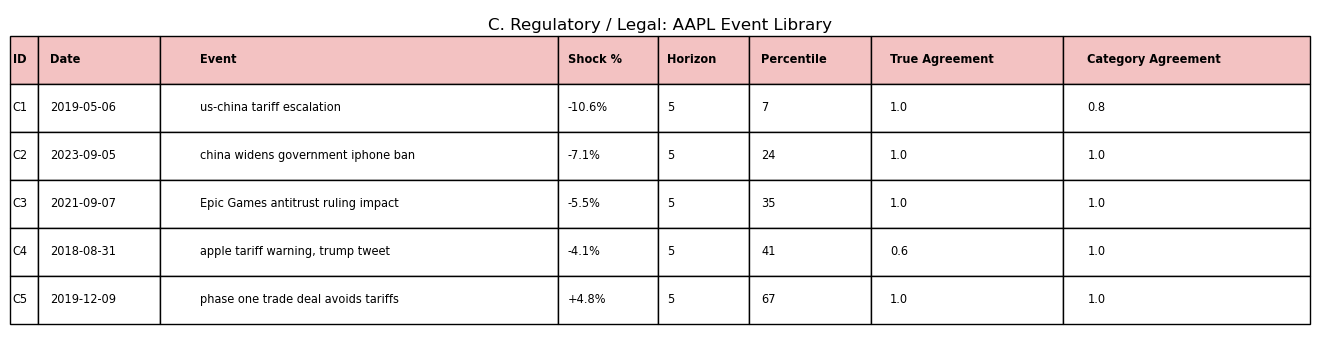

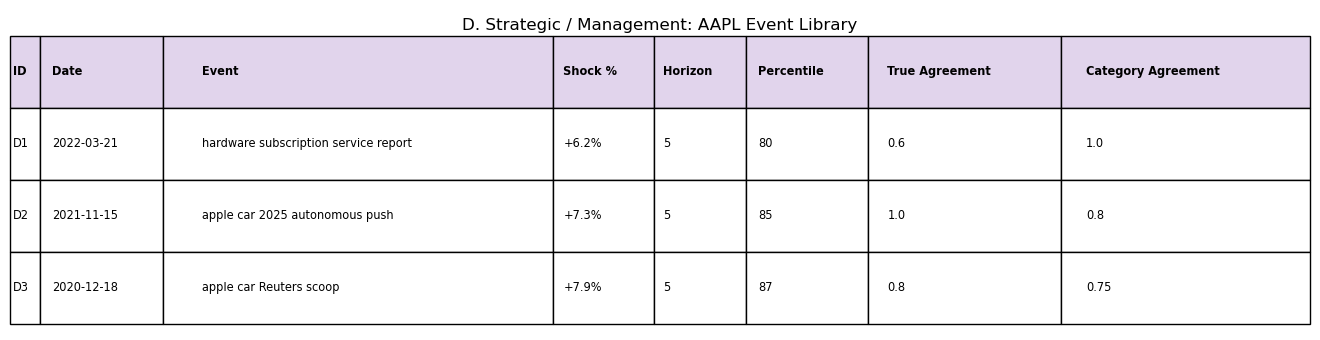

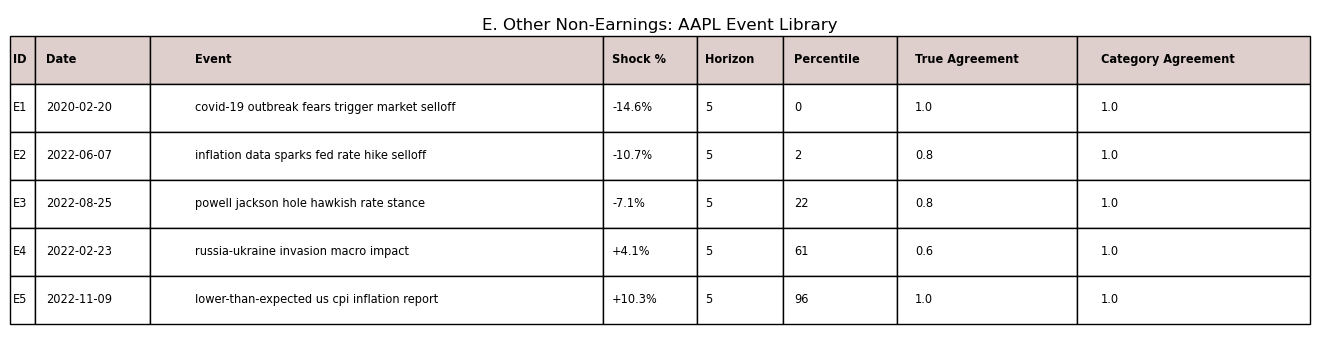

In [3]:

import numpy as np

import matplotlib.pyplot as plt

# ============================================================
# Configuration
# ============================================================
TICKER = "AAPL"

CATEGORY_COLORS = {
    "A. Earnings": "#1f77b4",
    "B. Product / Commercial": "#2ca02c",
    "C. Regulatory / Legal": "#d62728",
    "D. Strategic / Management": "#9467bd",
    "E. Other Non-Earnings": "#8c564b",
}

CATEGORY_ORDER = [
    "A. Earnings",
    "B. Product / Commercial",
    "C. Regulatory / Legal",
    "D. Strategic / Management",
    "E. Other Non-Earnings",
]

# ============================================================
# Helpers
# ============================================================
def lighten_color(hex_color, amount=0.85):
    hex_color = hex_color.lstrip("#")
    rgb = np.array([int(hex_color[i:i+2], 16) for i in (0, 2, 4)], dtype=float)
    white = np.array([255.0, 255.0, 255.0])
    blended = rgb + (white - rgb) * amount
    blended = np.clip(blended, 0, 255).astype(int)
    return "#{:02x}{:02x}{:02x}".format(*blended)


def interpret_percentile(p):
    if p <= 10:
        return "Extreme downside"
    if p <= 25:
        return "Lower-tail downside"
    if p < 75:
        return "Typical range"
    if p < 90:
        return "Upper-tail upside"
    return "Extreme upside"


def format_shock_pct(x):
    return f"{100.0 * x:+.1f}%"


def normalize_llm_category(cat: Optional[str]) -> str:
    mapping = {
        "Product / Commercial": "B. Product / Commercial",
        "Regulatory / Legal": "C. Regulatory / Legal",
        "Strategic / Management": "D. Strategic / Management",
        "Other Non-Earnings": "E. Other Non-Earnings",
    }
    if cat not in mapping:
        raise ValueError(f"Unknown llm category: {cat}")
    return mapping[cat]


def build_dataframe_from_all_events(earn_windows, llmselected):
    rows = []

    # Earnings
    for i, w in enumerate(earn_windows):
        rows.append({
            "Source": "earnings",
            "Category": "A. Earnings",
            "Date": pd.Timestamp(w.start_date+pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
            "Event": f"Earnings {i+1}",
            "Shock": float(w.simple_return),
            "Horizon": int(w.horizon),  
            "True Agreement": 1.0,
            "Category Agreement": 1.0,
        })

    # LLM-selected non-earnings events
    for w in llmselected:
        cat = getattr(w, "llm_category", None)
        if cat is None:
            continue

        rows.append({
            "Source": "llm",
            "Category": normalize_llm_category(cat),
            "Date": pd.Timestamp(w.start_date).strftime("%Y-%m-%d"),
            "Event": getattr(w, "llm_note", "") or "",
            "Shock": float(w.simple_return),
            "Horizon": int(w.horizon), 
            "True Agreement": float(getattr(w, "llm_true_agreement", np.nan)),
            "Category Agreement": float(getattr(w, "llm_category_agreement", np.nan)),
        })

    df = pd.DataFrame(rows)

    if df.empty:
        raise ValueError("No events found.")

    return df


def add_global_percentiles(df):
    df = df.sort_values("Shock", ascending=True).reset_index(drop=True).copy()
    n = len(df)

    if n == 1:
        percentiles = np.array([50], dtype=int)
    else:
        ranks = np.arange(n, dtype=float)
        percentiles = np.rint(ranks / (n - 1) * 100.0).astype(int)

    df["Percentile"] = percentiles
    return df


def add_category_ids(df):
    df = df.copy()
    df["ID"] = ""

    for category in CATEGORY_ORDER:
        subset_idx = df.index[df["Category"] == category].tolist()
        if not subset_idx:
            continue

        prefix = category.split(".")[0].strip()
        ids = [f"{prefix}{i+1}" for i in range(len(subset_idx))]
        for row_idx, event_id in zip(subset_idx, ids):
            df.at[row_idx, "ID"] = event_id

    return df


def build_global_table(df):
    return df[
        [
            "ID", "Category", "Date", "Event", "Shock %",
            "Horizon", 
            "Percentile", "True Agreement", "Category Agreement"
        ]
    ].copy()


def build_category_tables(df):
    tables = {}
    for category in CATEGORY_ORDER:
        subset = df[df["Category"] == category].copy()
        if subset.empty:
            continue

        subset = subset[
            [
                "ID", "Date", "Event", "Shock %",
                "Horizon",  
                "Percentile", "True Agreement", "Category Agreement"
            ]
        ]
        tables[category] = subset
    return tables


def draw_table_figure(
    table_df,
    title,
    header_color=None,
    row_category_colors=None,
    figsize=(13, 4.5),
    fontsize=8.0,
    yscale=0.15,
):
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")

    tbl = ax.table(
        cellText=table_df.values,
        colLabels=table_df.columns.tolist(),
        cellLoc="left",
        colLoc="left",
        bbox=[0.0, 0.02, 1.0, 0.9]
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(fontsize)
    tbl.scale(1.0, yscale)
    tbl.auto_set_column_width(col=list(range(len(table_df.columns))))


    col_positions = {name: i for i, name in enumerate(table_df.columns.tolist())}

    for (row, col), cell in tbl.get_celld().items():
        cell.PAD = 0.1
        if row == 0:
            cell.set_text_props(weight="bold")
            if header_color is not None:
                cell.set_facecolor(header_color)
        elif row > 0 and row_category_colors is not None:
            if "Category" in table_df.columns:
                category_name = table_df.iloc[row - 1]["Category"]
                tint = lighten_color(row_category_colors[category_name], amount=0.88)
                cell.set_facecolor(tint)

                if col == col_positions["Category"]:
                    cell.set_facecolor(
                        lighten_color(row_category_colors[category_name], amount=0.72)
                    )

    if title:
        ax.text(
            0.5, 0.985,
            title,
            transform=ax.transAxes,
            ha="center",
            va="top",
            fontsize=11,
        )

    ax.set_position([0, 0, 1, 1])
    fig.subplots_adjust(top=1, bottom=0, left=0, right=1)

    return fig, ax


# ============================================================
# Build combined data
# ============================================================
df = build_dataframe_from_all_events(earn_windows, llmselected)
df = add_global_percentiles(df)
df = add_category_ids(df)
df["Interpretation"] = df["Percentile"].map(interpret_percentile)
df["Shock %"] = df["Shock"].map(format_shock_pct)

df["True Agreement"] = df["True Agreement"].map(
    lambda x: None if pd.isna(x) else round(float(x), 2)
)
df["Category Agreement"] = df["Category Agreement"].map(
    lambda x: None if pd.isna(x) else round(float(x), 2)
)

global_table = build_global_table(df)
category_tables = build_category_tables(df)

# ============================================================
# Figure 1: Plot only
# ============================================================
fig_plot, ax_plot = plt.subplots(figsize=(13, 8))

for category_name in CATEGORY_ORDER:
    subset = df[df["Category"] == category_name]
    if subset.empty:
        continue

    ax_plot.scatter(
        subset["Shock"].to_numpy(),
        subset.index.to_numpy(),
        s=20,
        color=CATEGORY_COLORS[category_name],
        label=category_name,
        zorder=3
    )

for row_idx, row in df.iterrows():
    ax_plot.text(
        x=row["Shock"] + 0.0012,
        y=row_idx,
        s=row["ID"],
        va="center",
        fontsize=6
    )

tick_positions = np.arange(0, len(df), 2, dtype=int)
tick_labels = [f"{int(df.loc[i, 'Percentile'])}th" for i in tick_positions]

ax_plot.set_yticks(tick_positions)
ax_plot.set_yticklabels(tick_labels, fontsize=7)
ax_plot.set_ylabel("Percentile Rank")
ax_plot.set_xlabel("Return over window")
ax_plot.set_title(f"Historical Event Positioning: {TICKER}")

for q in (25, 50, 75):
    q_val = np.percentile(df["Shock"].to_numpy(), q)
    ax_plot.axvline(q_val, linestyle="--", alpha=0.30, linewidth=1.0, zorder=1)

ax_plot.grid(axis="x", alpha=0.15)
ax_plot.legend(frameon=False, ncol=2, fontsize=7)

plt.tight_layout()

# ============================================================
# Figure 2: Global table only
# ============================================================
global_rows = len(global_table)
global_height = max(4.5, 0.34 * global_rows + 1.6)

fig_global, ax_global = draw_table_figure(
    table_df=global_table,
    title="",
    header_color="#e6e6e6",
    row_category_colors=CATEGORY_COLORS,
    figsize=(13, global_height),
    fontsize=7.8,
    yscale=1.18,
)

ax_global.text(
    0.5, 0.975,
    f"Combined Event Library: {TICKER}",
    transform=ax_global.transAxes,
    ha="center",
    va="top",
    fontsize=12,
)

ax_global.set_position([0, 0.06, 1, 0.94])
fig_global.subplots_adjust(top=1, bottom=0, left=0, right=1)

# ============================================================
# Figures 3+: One standalone figure per category table
# ============================================================
category_figures = {}

for category_name, table_df in category_tables.items():
    n_rows = len(table_df)
    fig_height = max(3.2, 0.34 * n_rows + 1.4)

    fig_cat, ax_cat = draw_table_figure(
        table_df=table_df,
        title="",
        header_color=lighten_color(CATEGORY_COLORS[category_name], amount=0.72),
        row_category_colors=None,
        figsize=(13, fig_height),
        fontsize=8.2,
        yscale=1.18,
    )

    ax_cat.text(
        0.5, 0.975,
        f"{category_name}: {TICKER} Event Library",
        transform=ax_cat.transAxes,
        ha="center",
        va="top",
        fontsize=12,
    )

    ax_cat.set_position([0, 0.06, 1, 0.94])
    fig_cat.subplots_adjust(top=1, bottom=0, left=0, right=1)

    category_figures[category_name] = (fig_cat, ax_cat)

plt.show()
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

fig_plot.savefig(FIGURE_DIR / "aapl_event_positioning.png", dpi=200, bbox_inches="tight")
fig_global.savefig(FIGURE_DIR / "aapl_event_table.png", dpi=200, bbox_inches="tight")